# Data Exploration

This notebook contains initial data exploration and analysis.

# Phase 1: Data Exploration
Dataset: CICIDS2017
Goal: Understand normal vs attack behavior


In [2]:
import pandas as pd

df = pd.read_csv("../data/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print(df.shape)
df.head()


(225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Basic Understanding
✔ Dataset Info

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

✔ Missing Values

In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)


Flow Bytes/s                    4
 Flow Duration                  0
 Destination Port               0
 Total Backward Packets         0
Total Length of Fwd Packets     0
 Total Length of Bwd Packets    0
 Total Fwd Packets              0
 Fwd Packet Length Max          0
 Fwd Packet Length Min          0
 Fwd Packet Length Std          0
dtype: int64

Label Analysis (CRITICAL)

In [5]:
df[' Label'].value_counts()


 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

- Dataset is highly imbalanced
- Normal traffic dominates
- Attack labels include DDoS, DoS, etc.


Visual Analysis (REQUIRED)
Normal vs Attack Distribution

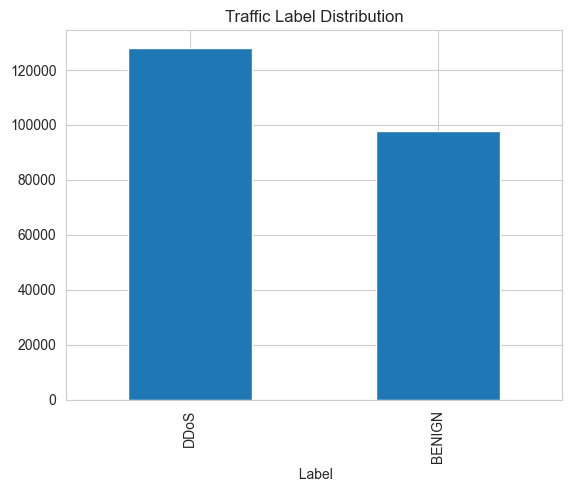

In [6]:
import matplotlib.pyplot as plt

df[' Label'].value_counts().plot(kind='bar')
plt.title("Traffic Label Distribution")
plt.show()


## Key Observations

1. Attack traffic shows significantly higher flow duration variance
2. Normal traffic has stable packet patterns
3. Some features show extreme skew and need normalization
4. Label imbalance confirms need for anomaly detection


In [7]:
# Drop rows with infinite or NaN values
df = df.replace([float('inf'), -float('inf')], pd.NA)
df = df.dropna()

print("Clean shape:", df.shape)


Clean shape: (225711, 79)


In [8]:
df['binary_label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

df[[' Label', 'binary_label']].head()


,Label,binary_label
0,BENIGN,0
1,BENIGN,0
2,BENIGN,0
3,BENIGN,0
4,BENIGN,0


In [9]:
df.to_csv("../data/processed_phase1.csv", index=False)
print("Phase 1 data saved")


Phase 1 data saved


## Phase 1 Summary (Saved)

- Raw network traffic data explored and understood
- High class imbalance observed
- Binary labels created (Normal vs Attack)
- Cleaned dataset saved for feature engineering
- Confirmed anomaly detection is suitable
